# 04회 - 차량 연비 예측

#### Q01.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Q02.

In [3]:
mpg_df = pd.read_excel('../datasets/auto_mpg.xlsx')
mpg_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1,chevrolet chevelle malibu
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1,buick skylark 320
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1,plymouth satellite
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1,amc rebel sst
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1,ford torino


#### Q03.

In [4]:
mpg_df.rename(columns={
     'mpg': '연비',
    'cylinders': '실린더 수',
    'displacement': '배기량',
    'horsepower': '마력',
    'weight': '차량 무게',
    'acceleration': '가속 성능',
    'model_year': '차량 출시 연도',
    'origin': '제조 국가 코드',
    'name': '차량 이름'
}, inplace=True)

mpg_df.columns

Index(['연비', '실린더 수', '배기량', '마력', '차량 무게', '가속 성능', '차량 출시 연도', '제조 국가 코드',
       '차량 이름'],
      dtype='str')

#### Q04.

In [9]:
del_df = mpg_df.dropna()

#### Q05.

In [13]:
import matplotlib.font_manager as fm
import platform

# 운영체제별 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':  # macOS
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')  # 리눅스: 나눔고딕 설치 필요

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

<Axes: xlabel='마력', ylabel='연비'>

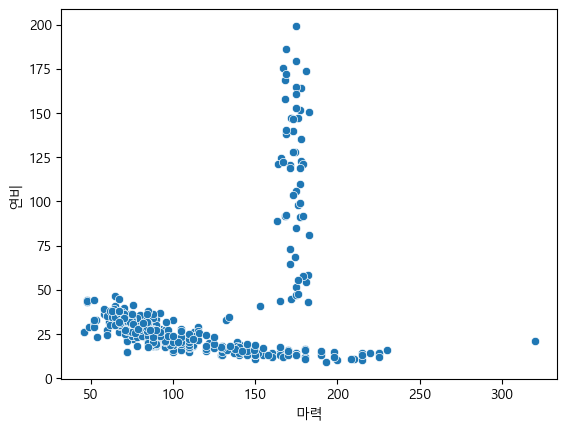

In [22]:
sns.scatterplot(data=del_df, x='마력', y='연비')

In [27]:
del_df.drop(del_df[(del_df['마력'] >= 150) & (del_df['연비'] > 50)].index, inplace=True)

<Axes: xlabel='마력', ylabel='연비'>

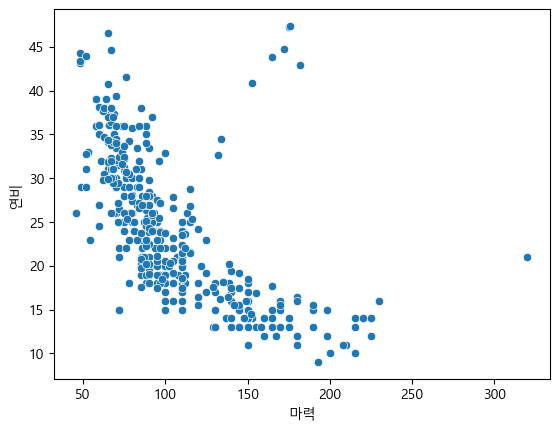

In [28]:
sns.scatterplot(data=del_df, x='마력', y='연비')

#### Q06.

In [29]:
col_list = ['배기량','마력','차량 무게','가속 성능']

<Axes: >

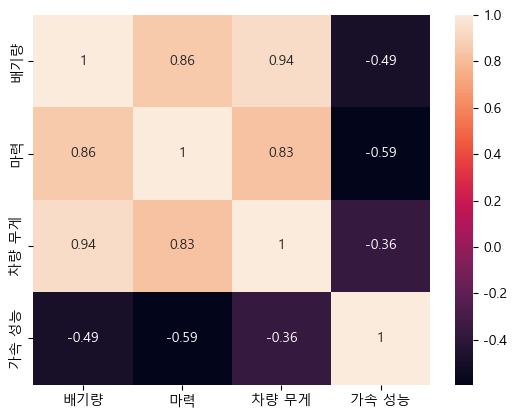

In [31]:
sns.heatmap(del_df[col_list].corr(), annot=True)

#### Q07.

In [35]:
# clear_df = del_df.drop(['차량 무게', '차량 출시 연도', '제조 국가 코드', '차량 이름'], axis=1)
clear_df = del_df.drop(columns=['차량 무게', '차량 출시 연도', '제조 국가 코드', '차량 이름'])
clear_df

,연비,실린더 수,배기량,마력,가속 성능
0,18.00,8.0,307.0,130.0,12.0
1,15.00,8.0,350.0,165.0,11.5
2,18.00,8.0,318.0,150.0,11.0
3,16.00,8.0,304.0,150.0,12.0
4,17.00,8.0,302.0,140.0,10.5
...,...,...,...,...,...
429,43.88,4.0,380.0,165.0,20.1
451,44.78,8.0,376.0,172.0,19.9
460,42.88,4.0,394.0,182.0,20.1
463,47.21,4.0,386.0,175.0,20.5


#### Q08.

In [39]:
encoding_df = pd.get_dummies(data=clear_df, columns=['실린더 수'], drop_first=True)
encoding_df

,연비,배기량,마력,가속 성능,실린더 수_4.0,실린더 수_5.0,실린더 수_6.0,실린더 수_8.0
0,18.00,307.0,130.0,12.0,False,False,False,True
1,15.00,350.0,165.0,11.5,False,False,False,True
2,18.00,318.0,150.0,11.0,False,False,False,True
3,16.00,304.0,150.0,12.0,False,False,False,True
4,17.00,302.0,140.0,10.5,False,False,False,True
...,...,...,...,...,...,...,...,...
429,43.88,380.0,165.0,20.1,True,False,False,False
451,44.78,376.0,172.0,19.9,False,False,False,True
460,42.88,394.0,182.0,20.1,True,False,False,False
463,47.21,386.0,175.0,20.5,True,False,False,False


#### Q09.

In [40]:
from sklearn.model_selection import train_test_split

X = encoding_df.drop(columns=['연비'])
y = encoding_df['연비']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42)

#### Q10.

In [41]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [42]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_valid)

#### Q11.

In [43]:
from sklearn.svm import SVR

In [44]:
svr = SVR(kernel='rbf', C=1.0, epsilon=0.2)
svr.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.2
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


#### Q12.

In [45]:
from sklearn.ensemble import RandomForestRegressor

In [46]:
rfc = RandomForestRegressor(
    n_estimators=200, 
    max_depth=10, 
    min_samples_split=7, 
    random_state=42)

rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

#### Q13.

In [47]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
tf.random.set_seed(42)

In [58]:
model = Sequential()
model.add(Dense(32, activation='tanh'))
model.add(Dropout(0.3))
model.add(Dense(24, activation='tanh'))
model.add(Dropout(0.3))
model.add(Dense(16, activation='tanh'))
model.add(Dense(8, activation='tanh'))
model.add(Dense(1, activation='linear'))

model.compile(
    optimizer='rmsprop',
    loss='mean_absolute_error',
    metrics=['mean_squared_error']
)

model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 23.3554 - mean_squared_error: 604.2170
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22.2077 - mean_squared_error: 552.6296
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 20.7998 - mean_squared_error: 498.3721
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 19.8228 - mean_squared_error: 459.4897
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.2760 - mean_squared_error: 438.5185
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 18.8210 - mean_squared_error: 421.2279
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 18.4666 - mean_squared_error: 407.8246
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 18.0893 - mean_squared_error: 393.9551
Epoch 9/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 17.7286 - mean_squared_error: 380.9850
Epoch 10/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 17.2973 - mean_squared_error: 364.8527
Epoch 11/50
41/41 ━━━━━━━━━

#### Q14.

In [59]:
simul_data = np.array([[200.0, 95.0, 15.0, 1, 0, 0, 0]])

In [66]:
simul_data = scaler.transform(simul_data)

deep_pre = model.predict(simul_data)
print(deep_pre)

d:\dev\workspace\ai\aice_associate\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
[[-16.066849]]
